# **1. Import Necessary Libraries**

In [1]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.3 MB/s eta 0:00:00


In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import joblib
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML and Deep Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, roc_curve, auc

# Tensorflow
import tensorflow as tf

import keras_tuner
from keras_tuner import RandomSearch
import shap

# **2. Data Loading**

In [3]:
# Load data into a dataframe
df = pd.read_csv('fault_detection.csv')

In [4]:
# View the features
df.head()

,Timestamp,String_ID,G_front,G_rear,T_cell,Voltage_V,Current_A,Label
0,'2025-01-21 16:01:30,1,403.09,60.46,32.70,15.03,5.7351,Healthy
1,'2025-01-09 09:03:10,1,646.73,97.01,38.98,60.59,0.3583,Shading
2,'2025-01-15 12:50:20,2,958.63,143.79,47.33,98.34,0.1472,Shading
3,'2025-01-25 11:47:02,2,994.32,149.15,50.64,23.30,9.1039,Shading
4,'2025-01-27 08:39:25,2,529.60,79.44,37.78,25.51,4.1349,Shading


In [5]:
# Total samples
print("Total samples:", len(df))

Total samples: 100000


In [6]:
# Label value counts
df['Label'].value_counts()

,count
Label,
Healthy,25000
Shading,25000
Short Circuit,25000
Open Circuit,25000


In [7]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [8]:
df.isnull().sum()

,0
Timestamp,0
String_ID,0
G_front,0
G_rear,0
T_cell,0
Voltage_V,0
Current_A,0
Label,0


# **3. Data Preprocessing**

In [9]:
# Create power features
df['Power'] = df['Voltage_V'] * df['Current_A']

In [10]:
df['Irradiance_Total'] = df['G_front'] + df['G_rear'] # Total irradiance
df['Irradiance_Ratio'] = df['G_front'] / df['G_rear'] + 1e-10 # front / rear ratio
df['Resistance_Ohm'] = df['Voltage_V'] / (df['Current_A'] + 1e-10) # Resistance

# Time based
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['Month'] = df['Timestamp'].dt.month

# Irradiance patterns
df['G_diff'] = df['G_front'] - df['G_rear']

# Temperature deviation
df['Temp_diff'] = df['T_cell'] - df['T_cell'].rolling(window=5, min_periods=1).mean()

In [11]:
df.head()

,Timestamp,String_ID,G_front,G_rear,T_cell,Voltage_V,Current_A,Label,Power,Irradiance_Total,Irradiance_Ratio,Resistance_Ohm,Hour,DayOfWeek,Month,G_diff,Temp_diff
0,2025-01-21 16:01:30,1,403.09,60.46,32.70,15.03,5.7351,Healthy,86.198553,463.55,6.667053,2.620704,16,1,1,342.63,0.0000
1,2025-01-09 09:03:10,1,646.73,97.01,38.98,60.59,0.3583,Shading,21.709397,743.74,6.666632,169.104103,9,3,1,549.72,3.1400
2,2025-01-15 12:50:20,2,958.63,143.79,47.33,98.34,0.1472,Shading,14.475648,1102.42,6.666875,668.070652,12,2,1,814.84,7.6600
3,2025-01-25 11:47:02,2,994.32,149.15,50.64,23.30,9.1039,Shading,212.120870,1143.47,6.666577,2.559343,11,5,1,845.17,8.2275
4,2025-01-27 08:39:25,2,529.60,79.44,37.78,25.51,4.1349,Shading,105.481299,609.04,6.666667,6.169436,8,0,1,450.16,-3.7060


In [12]:
# Remove timestamp and string ID
df = df.drop(['Timestamp', 'String_ID'], axis=1)
print("Total features:", len(df.columns))

Total features: 15


In [13]:
# Get the required features
feats = [col for col in df.columns if col != 'Label']

# **4. Train Test Splitting**

In [14]:
# Seperate data
X = df[feats].values
y = df['Label'].values

In [15]:
# Encoding
ohe = OneHotEncoder()
y = ohe.fit_transform(y.reshape(-1, 1)).toarray()
y

array([[1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.]])

In [16]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [17]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
# View total samples
print("Training set:", len(X_train),"samples")
print("Testing set:", len(X_test),"samples")

Training set: 80000 samples
Testing set: 20000 samples


In [19]:
df.columns

Index(['G_front', 'G_rear', 'T_cell', 'Voltage_V', 'Current_A', 'Label',
       'Power', 'Irradiance_Total', 'Irradiance_Ratio', 'Resistance_Ohm',
       'Hour', 'DayOfWeek', 'Month', 'G_diff', 'Temp_diff'],
      dtype='object')

# **5. Building the Neural Network**

In [20]:
def build_ann(input_dim, output_dim):
  """
  Builds a neural network model for fault detection
  """

  model = tf.keras.models.Sequential([
      # Define input
      tf.keras.layers.Input((input_dim, )),

      # Hidden layer #1
      tf.keras.layers.Dense(128, activation='relu'),
      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Dropout(0.2),

      # Hidden layer # 2
      tf.keras.layers.Dense(64, activation='relu'),
      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Dropout(0.2),

      # Hidden layer # 3
      tf.keras.layers.Dense(32, activation='relu'),
      tf.keras.layers.BatchNormalization(),
      tf.keras.layers.Dropout(0.2),

      # Define output layer
      tf.keras.layers.Dense(output_dim, activation='softmax')
  ])

  return model

In [21]:
# Define input and output shapes
input_dim = X_train.shape[1]
output_dim = y_train.shape[1]

In [22]:
# Build the ANN
ann = build_ann(input_dim, output_dim)

In [23]:
# Compile model
ann.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',  # use categorical cross entropy for one hot encoded labels
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')]
)

In [24]:
# Show the models' summary
ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,284 (51.89 KB)

 Trainable params: 12,836 (50.14 KB)

 Non-trainable params: 448 (1.75 KB)

# **6. Training the Neural Network**

In [25]:
# Define call backs for early stopping
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,    # stop after 10 epochs if no improvement
        restore_best_weights=True # return back to the best model
    )
]

# Fit the ANN
history = ann.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - accuracy: 0.7094 - auc: 0.9128 - loss: 0.6718 - precision: 0.7488 - recall: 0.6584 - val_accuracy: 0.9225 - val_auc: 0.9929 - val_loss: 0.2035 - val_precision: 0.9409 - val_recall: 0.9010
Epoch 2/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8800 - auc: 0.9854 - loss: 0.2785 - precision: 0.8921 - recall: 0.8692 - val_accuracy: 0.9284 - val_auc: 0.9946 - val_loss: 0.1720 - val_precision: 0.9515 - val_recall: 0.9068
Epoch 3/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9009 - auc: 0.9901 - loss: 0.2278 - precision: 0.9150 - recall: 0.8916 - val_accuracy: 0.9398 - val_auc: 0.9962 - val_loss: 0.1403 - val_precision: 0.9544 - val_recall: 0.9277
Epoch 4/20
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9144 - auc: 0.9922 - loss: 0.2017 - precision: 0.9280 - recall: 0.9050 - val_accuracy: 0.9251 - val_auc: 0.9949 - val_loss: 0.1600 - val_precision: 0.9441 - val_recall: 0.9098
Epoch 5/20
2500/250

# **7. Evaluate Neural Network**

In [26]:
# Evaluate on test set
test_results = ann.evaluate(X_test, y_test, verbose=0)

metrics = ['Loss', 'Accuracy', 'Precision', 'Recall', 'AUC']

df_results = pd.DataFrame(
  [np.round(test_results, 3)],
  columns=[f'Test {m}' for m in metrics]
)
df_results

,Test Loss,Test Accuracy,Test Precision,Test Recall,Test AUC
0,0.091,0.962,0.979,0.95,0.998


In [27]:
# Get predictions
y_pred_proba = ann.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

# **8. Display Results**

In [28]:
def display_history(history):
  """
  Plots the ANN;s training metrics
  """

  fig, axes = plt.subplots(2, 3, figsize=(15, 10))

  plt.suptitle('Plots of All Neural Network\'s Metrics', fontsize=20, fontweight='bold')

  # Accuracy
  axes[0, 0].plot(history.history['accuracy'], label='Train', c='blue')
  axes[0, 0].plot(history.history['val_accuracy'], label='Validation', c='red')
  axes[0, 0].set_title('ANN Accuracy')
  axes[0, 0].set_ylabel('Accuracy')
  axes[0, 0].set_xlabel('Epoch')
  axes[0, 0].legend()

  # Loss
  axes[0, 1].plot(history.history['loss'], label='Train', c='blue')
  axes[0, 1].plot(history.history['val_loss'], label='Validation', c='red')
  axes[0, 1].set_title('ANN Loss')
  axes[0, 1].set_ylabel('Loss')
  axes[0, 1].set_xlabel('Epoch')
  axes[0, 1].legend()

  # Precision
  axes[0, 2].plot(history.history['precision'], label='Train', c='blue')
  axes[0, 2].plot(history.history['val_precision'], label='Validation', c='red')
  axes[0, 2].set_title('ANN Precision')
  axes[0, 2].set_ylabel('Precision')
  axes[0, 2].set_xlabel('Epoch')
  axes[0, 2].legend()

  # Recall
  axes[1, 0].plot(history.history['precision'], label='Train', c='blue')
  axes[1, 0].plot(history.history['val_precision'], label='Validation', c='red')
  axes[1, 0].set_title('ANN Precision')
  axes[1, 0].set_ylabel('Precision')
  axes[1, 0].set_xlabel('Epoch')
  axes[1, 0].legend()

  # AUC
  axes[1, 1].plot(history.history['auc'], label='Train', c='blue')
  axes[1, 1].plot(history.history['val_auc'], label='Validation', c='red')
  axes[1, 1].set_title('ANN AUC')
  axes[1, 1].set_ylabel('AUC')
  axes[1, 1].set_xlabel('Epoch')
  axes[1, 1].legend()

  plt.tight_layout()
  plt.show()

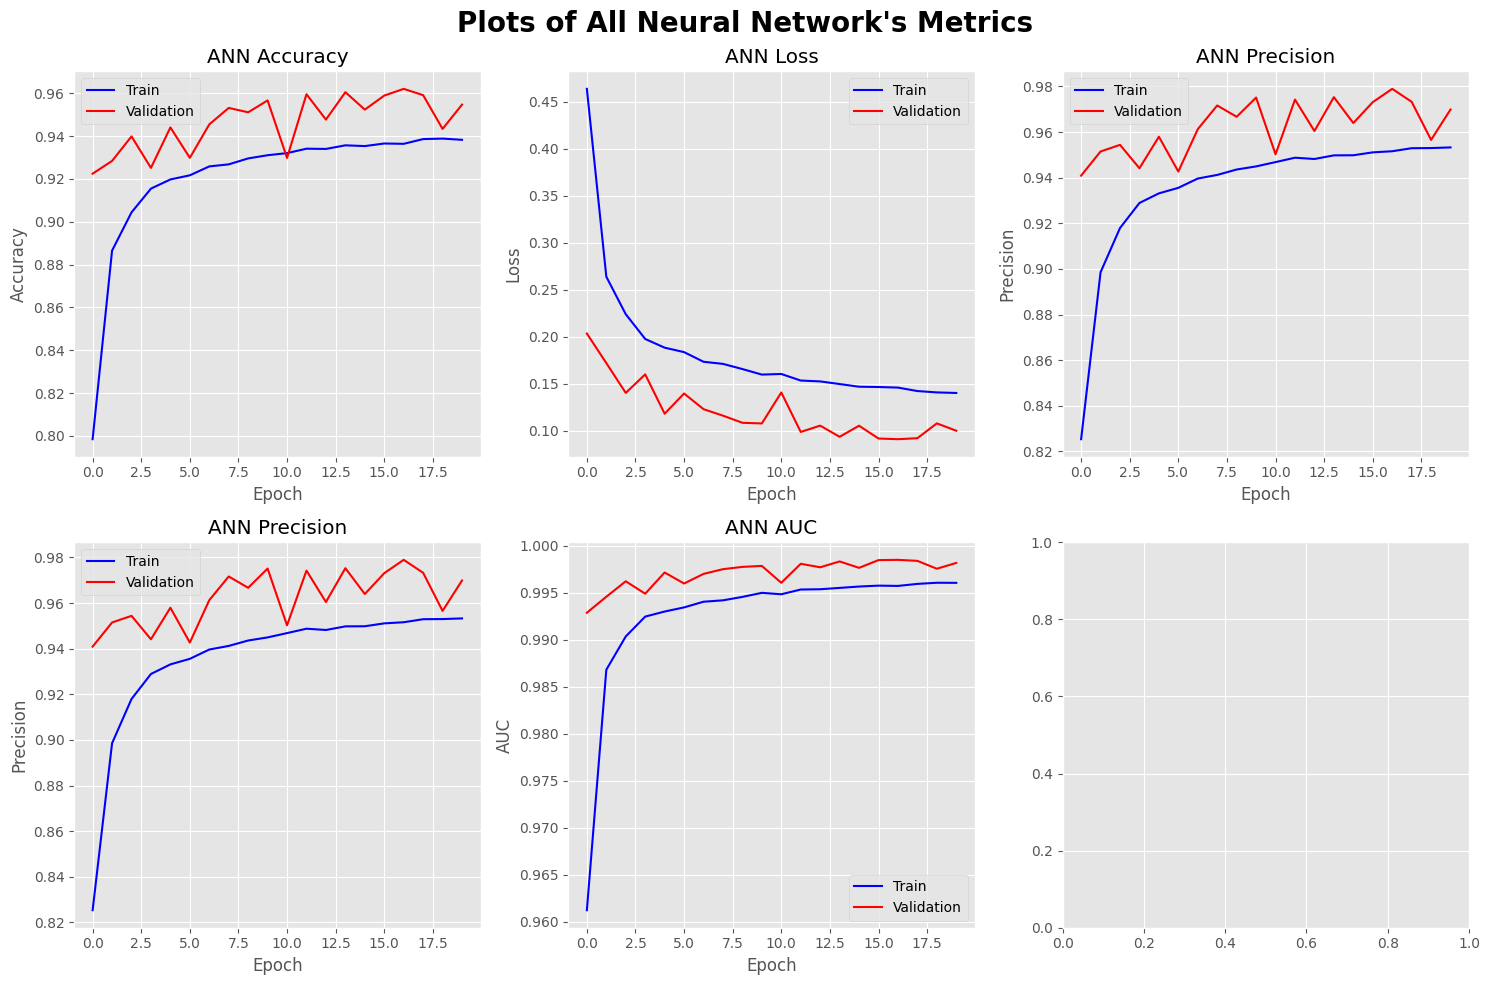

In [29]:
# Display the ANN's history
display_history(history)

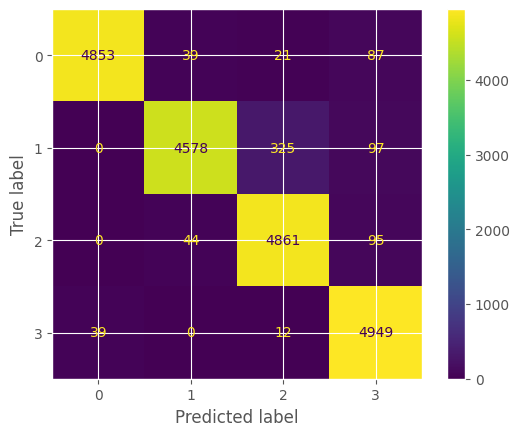

In [30]:
# Visualize confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [31]:
# View classification report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      5000
           1       0.98      0.92      0.95      5000
           2       0.93      0.97      0.95      5000
           3       0.95      0.99      0.97      5000

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000



# **9. Hyperparameter Tuning**

In [32]:
# Perform hyparameter tuning
def tune(parameter):
  """
  Build ANN model with tunable hyperparameters
  """

  model = tf.keras.Sequential()

  # Input layer
  model.add(tf.keras.layers.Input(shape=(X_train.shape[1], )))

  # Tunable (no. of hidden layers)
  n_layers = parameter.Int('num_layers', min_value=1, max_value=6, default=3)

  for i in range(n_layers):
    units = parameter.Int(f'units_layer_{i}', min_value=16, max_value=256, step=16)

    model.add(tf.keras.layers.Dense(
        units=units,
        activation=parameter.Choice(f'activation_layer_{i}', ['relu', 'tanh', 'elu'])
    ))

    # Add batch normalization to reduce overfitting
    model.add(tf.keras.layers.BatchNormalization())

    # Adjust dropout rates
    dropout_rate = parameter.Float(f'drop_out_{i}', min_value=0.0, max_value=0.5, step=0.1)
    if dropout_rate > 0:
      model.add(tf.keras.layers.Dropout(dropout_rate))

    # Output layer
  model.add(tf.keras.layers.Dense(output_dim, activation='softmax'))

  # Learning rate
  lr = parameter.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

  # Optimizer
  optimizer_name = parameter.Choice('optimizer', ['adam', 'rmsprop', 'sgd'])

  if optimizer_name == "adam":
    optimizer = tf.optimizers.Adam(learning_rate=lr)
  elif optimizer_name == "rmsprop":
    optimizer = tf.optimizers.RMSprop(learning_rate=lr)
  else:
    optimizer = tf.optimizers.SGD(learning_rate=lr)

  # Finally, compile the model
  model.compile(
      optimizer=optimizer,
      loss='categorical_crossentropy',
      metrics=['accuracy', 'precision', 'recall', 'auc']
  )

  return model

In [33]:
# Run hyparapemeter search
tuner = RandomSearch(
    tune,
    objective='val_accuracy', # targetting val accuracy, optimize it to the maximum
    max_trials=10,    # test upto 10 different hyperparameter combinations
    executions_per_trial=2, # each trial runs twice and averaged
    directory='fault_detection/tuner_results'
)

In [34]:
# Perform searching
tuner.search(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        mode='max'    # Highest is always best
    )],
    verbose=1
)

Trial 10 Complete [00h 05m 52s]
val_accuracy: 0.9248499870300293

Best val_accuracy So Far: 0.9699749946594238
Total elapsed time: 01h 28m 57s


In [35]:
# Get the best parameters
best_hyper_params = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
best_hyper_params.values

Best hyperparameters:


{'num_layers': 6,
 'units_layer_0': 160,
 'activation_layer_0': 'relu',
 'drop_out_0': 0.4,
 'units_layer_1': 160,
 'activation_layer_1': 'elu',
 'drop_out_1': 0.0,
 'units_layer_2': 80,
 'activation_layer_2': 'relu',
 'drop_out_2': 0.1,
 'learning_rate': 0.00023205078892812612,
 'optimizer': 'adam',
 'units_layer_3': 96,
 'activation_layer_3': 'relu',
 'drop_out_3': 0.2,
 'units_layer_4': 192,
 'activation_layer_4': 'tanh',
 'drop_out_4': 0.4,
 'units_layer_5': 160,
 'activation_layer_5': 'relu',
 'drop_out_5': 0.30000000000000004}

In [36]:
# Best layers
print("Best number of layers:", best_hyper_params.get('num_layers'))

Best number of layers: 6


In [37]:
# Iterate through architecture
for i in range(best_hyper_params.get('num_layers')):
  print(f"Best number of units in layer:", best_hyper_params.get(f'units_layer_{i}'))
  print(f"Best dropout rate:", best_hyper_params.get(f'drop_out_{i}'))
  print("Best learning rate:", best_hyper_params.get('learning_rate'))

Best number of units in layer: 160
Best dropout rate: 0.4
Best learning rate: 0.00023205078892812612
Best number of units in layer: 160
Best dropout rate: 0.0
Best learning rate: 0.00023205078892812612
Best number of units in layer: 80
Best dropout rate: 0.1
Best learning rate: 0.00023205078892812612
Best number of units in layer: 96
Best dropout rate: 0.2
Best learning rate: 0.00023205078892812612
Best number of units in layer: 192
Best dropout rate: 0.4
Best learning rate: 0.00023205078892812612
Best number of units in layer: 160
Best dropout rate: 0.30000000000000004
Best learning rate: 0.00023205078892812612


# **10. Train the Best Model**

In [38]:
# Build using best params
best_model = tuner.hypermodel.build(best_hyper_params)

In [39]:
# Train the best model
history = best_model.fit(
    X_train,
    y_train,
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        mode='max'
    )],
    verbose=1
)

Epoch 1/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.5417 - auc: 0.8020 - loss: 1.1557 - precision: 0.5714 - recall: 0.4900 - val_accuracy: 0.8437 - val_auc: 0.9810 - val_loss: 0.3108 - val_precision: 0.8533 - val_recall: 0.8374
Epoch 2/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.7844 - auc: 0.9551 - loss: 0.4957 - precision: 0.8028 - recall: 0.7629 - val_accuracy: 0.8666 - val_auc: 0.9871 - val_loss: 0.2475 - val_precision: 0.8884 - val_recall: 0.8474
Epoch 3/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.8311 - auc: 0.9738 - loss: 0.3702 - precision: 0.8472 - recall: 0.8132 - val_accuracy: 0.8910 - val_auc: 0.9912 - val_loss: 0.2031 - val_precision: 0.9068 - val_recall: 0.8805
Epoch 4/30
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.8662 - auc: 0.9833 - loss: 0.2945 - precision: 0.8795 - recall: 0.8527 - val_accuracy: 0.9313 - val_auc: 0.9949 - val_loss: 0.1616 - val_precision: 0.9490 - val_recall: 0.9212
Epoch 5/30
2500/2500

In [ ]:
# Best model predictions
y_pred_proba_best = best_model.predict(X_test, verbose=0)
y_pred_best = np.argmax(y_pred_proba_best, axis=1)

In [ ]:
# Show the history
display_history(history)

In [ ]:
# Display confusion matrix
cm = confusion_matrix(y_true, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [ ]:
# Classification report
print(classification_report(y_true, y_pred_best))

In [ ]:
# Evaluate on test set
test_results = best_model.evaluate(X_test, y_test, verbose=0)

metrics = ['Loss', 'Accuracy', 'Precision', 'Recall', 'AUC']

df_results = pd.DataFrame(
  [np.round(test_results, 3)],
  columns=[f'Test {m}' for m in metrics]
)
df_results

# **11. SHAP Interpretability**

# **12. Save Best Model**

In [45]:
best_model.save('best_neural_network.h5')